# Phase-transition analysis: why does RL spike at phase boundaries while LLMs don't?

Observation from `heuristic_rl_rt_per_phase.ipynb` vs `llm_rt_per_phase.ipynb`:
at each phase boundary (low→medium at step 60, medium→high at step 120) the RL agents (PPO/DDPG/MDQN) show a noticeable RT spike, while the LLM agents stay flat.

This notebook tests four candidate explanations side-by-side, per method:

1. **Headroom** — LLMs may simply over-provision, so they have spare CPU when load jumps.
2. **Reactivity** — LLMs may scale up *faster* once the new load arrives.
3. **Pre-emption** — LLMs may scale up *before* the boundary (noisy observations triggering early action).
4. **Steady-state jitter** — LLMs may carry more variance in `cpu_limit` throughout, which incidentally cushions transitions.

Each gets a small quantitative block plus a comparison plot.

Data: `results/benchmark/small_1405/` (the run that has both RL and LLM iterations side by side). Change `RESULTS_DIR` below if you want to point at another sweep.

In [37]:
!pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 51.5 MB/s  0:00:00m0:00:010:01

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [1]:
import glob
import os
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
RESULTS_DIR = '../results/benchmark/small'

# (file_tag, display_name, group, color). group is used only for coloring/legend.
MODELS = [
    ('ppo',                       'PPO',         'RL',  '#1f77b4'),
    ('ddpg',                      'DDPG',        'RL',  '#aec7e8'),
    ('mdqn',                      'MDQN',        'RL',  '#17becf'),
    ('llm_vpa_ollama_llama3_8b',      'llama3:8b',   'LLM', '#d62728'),
    ('llm_vpa_ollama_qwen2_5_7b',     'qwen2.5:7b',  'LLM', '#ff7f0e'),
    ('llm_vpa_ollama_mistral_latest', 'mistral:7b',  'LLM', '#9467bd'),
    ('k8s_vpa',                 'VPA',   'HEU', '#2ca02c'),
]

# Steps where the phase changes. Hardcoded to match benchmark_config.yaml
# (60 steps per phase). Edit if you changed steps_per_phase.
TRANSITIONS = {'low→medium': 60, 'medium→high': 120}

# Window sizes around each transition.
PRE_W  = 10   # steps before transition used to define baseline
POST_W = 15   # steps after transition we look at for spike + recovery

In [3]:
def load_model(tag):
    files = sorted(glob.glob(os.path.join(RESULTS_DIR, f'{tag}_iter*_metrics.csv')))
    if not files:
        return None
    dfs = []
    for f in files:
        d = pd.read_csv(f)
        d['iter'] = int(os.path.basename(f).split('_iter')[1].split('_')[0])
        dfs.append(d)
    return pd.concat(dfs, ignore_index=True)


def parse_action(s):
    s = str(s).strip()
    if s.startswith('['):
        parts = s.strip('[]').split()
        return float(parts[0]), float(parts[1]) if len(parts) > 1 else 0.0
    try:
        return float(s), 0.0
    except Exception:
        return 0.0, 0.0


raw = {}
for tag, name, group, color in MODELS:
    d = load_model(tag)
    if d is None:
        print(f'  {name:12s} NO DATA')
        continue
    d[['vpa', 'hpa']] = pd.DataFrame(d['action'].map(parse_action).tolist(), index=d.index)
    raw[name] = {'df': d, 'group': group, 'color': color}
    print(f'  {name:12s} {group:3s}  iters={d["iter"].nunique():2d}  rows={len(d)}')

MODEL_NAMES = list(raw.keys())

  PPO          RL   iters=20  rows=7200
  DDPG         RL   iters=20  rows=7200
  MDQN         RL   iters=20  rows=7200
  llama3:8b    LLM  iters=20  rows=7200
  qwen2.5:7b   LLM  iters=20  rows=7200
  mistral:7b   LLM  iters=20  rows=7200
  VPA          HEU  iters=20  rows=7200


## 1. Quantify the spike

For each (model, iteration, agent, transition) compute three numbers:

- `baseline_rt`   = mean RT in `[T-PRE_W, T-1]`
- `peak_rt`       = max  RT in `[T,       T+POST_W]`
- `spike_ratio`   = peak_rt / baseline_rt  (1.0 = no spike)
- `recovery_steps` = steps after T until RT drops back below 1.2 × baseline (POST_W if never)

Aggregating across iterations and agents gives one number per (model, transition).

In [4]:
def spike_stats(df, T, pre_w=PRE_W, post_w=POST_W):
    rows = []
    for (it, ag), sub in df.groupby(['iter', 'agent_id']):
        sub = sub.sort_values('step')
        pre  = sub[(sub['step'] >= T - pre_w) & (sub['step'] <  T)]['response_time']
        post = sub[(sub['step'] >= T)          & (sub['step'] <  T + post_w)]['response_time']
        if len(pre) == 0 or len(post) == 0 or pre.mean() == 0:
            continue
        baseline = pre.mean()
        peak     = post.max()
        rec = post_w
        for k, rt in enumerate(post.values):
            if rt < 1.2 * baseline:
                rec = k
                break
        rows.append({'iter': it, 'agent': ag,
                     'baseline_rt': baseline, 'peak_rt': peak,
                     'spike_ratio': peak / baseline, 'recovery_steps': rec})
    return pd.DataFrame(rows)


summary_rows = []
for name, meta in raw.items():
    for label, T in TRANSITIONS.items():
        s = spike_stats(meta['df'], T)
        if s.empty:
            continue
        summary_rows.append({
            'model': name, 'group': meta['group'], 'transition': label,
            'baseline_ms':    s['baseline_rt'].mean() * 1000,
            'peak_ms':        s['peak_rt'].mean()     * 1000,
            'spike_ratio':    s['spike_ratio'].mean(),
            'recovery_steps': s['recovery_steps'].mean(),
        })
spike_df = pd.DataFrame(summary_rows)
spike_df.round(2)

,model,group,transition,baseline_ms,peak_ms,spike_ratio,recovery_steps
0,PPO,RL,low→medium,12.47,416.94,33.41,0.05
1,PPO,RL,medium→high,168.94,1442.88,6.04,0.28
2,DDPG,RL,low→medium,15.35,1324.88,95.82,0.02
3,DDPG,RL,medium→high,190.17,1587.56,33.57,0.22
4,MDQN,RL,low→medium,18.98,1523.15,95.43,0.05
5,MDQN,RL,medium→high,273.49,3443.87,107.83,0.00
6,llama3:8b,LLM,low→medium,8.99,379.35,38.90,0.65
7,llama3:8b,LLM,medium→high,172.39,1237.27,4.94,0.05
8,qwen2.5:7b,LLM,low→medium,9.35,610.39,76.10,0.92
9,qwen2.5:7b,LLM,medium→high,223.66,3149.21,23.34,0.00


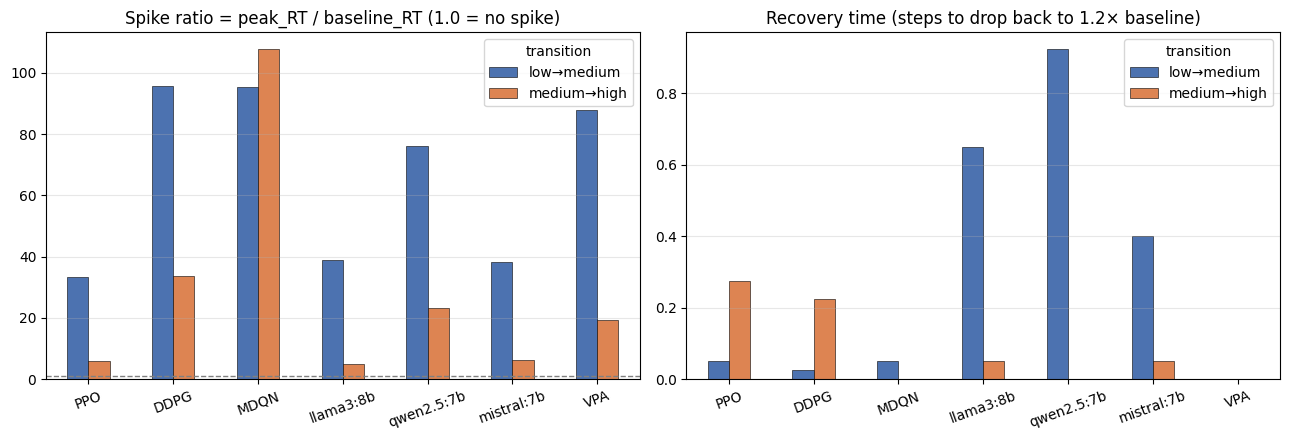

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, metric, title in zip(axes,
                              ['spike_ratio', 'recovery_steps'],
                              ['Spike ratio = peak_RT / baseline_RT (1.0 = no spike)',
                               'Recovery time (steps to drop back to 1.2× baseline)']):
    pivot = spike_df.pivot(index='model', columns='transition', values=metric).loc[MODEL_NAMES]
    pivot.plot(kind='bar', ax=ax, color=['#4c72b0', '#dd8452'], edgecolor='black', linewidth=0.4)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(True, axis='y', alpha=0.3)
    if metric == 'spike_ratio':
        ax.axhline(1.0, color='gray', linewidth=1, linestyle='--')
plt.tight_layout()
plt.show()

## 2. RT around each boundary

Mean RT over a window centred on each transition. Solid — LLM/heuristic; dashed — RL. If RL's curve climbs sharply after `step = T` while LLM's stays flat, the spike pattern is real and not an artefact of averaging.

/var/folders/_w/wjrd18051s799vj3r9b2k_cw0000gn/T/ipykernel_76008/3740124214.py:15: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 1e4)
/var/folders/_w/wjrd18051s799vj3r9b2k_cw0000gn/T/ipykernel_76008/3740124214.py:15: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 1e4)


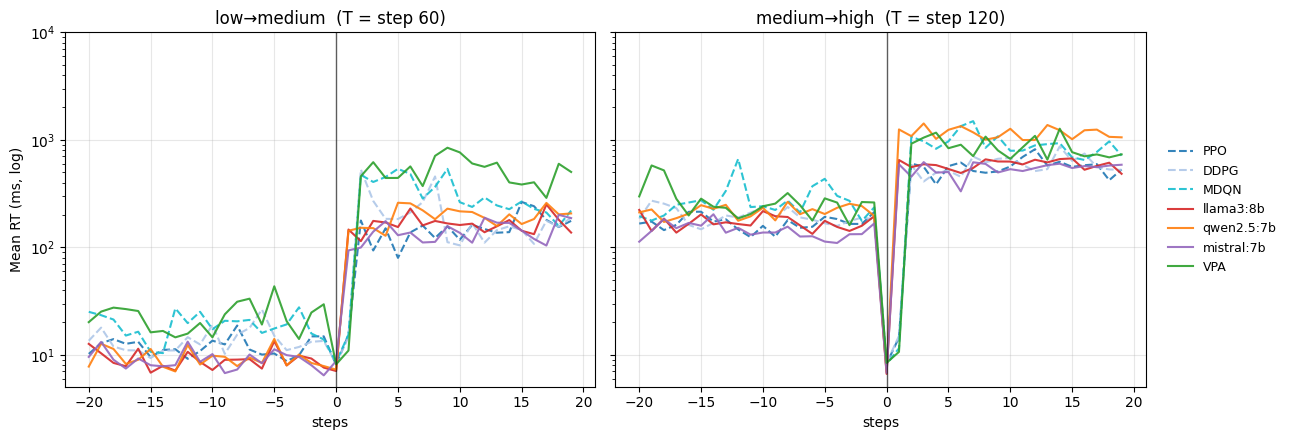

In [9]:
W = 20  # symmetric window around the transition

fig, axes = plt.subplots(1, len(TRANSITIONS), figsize=(13, 4.5), sharey=True)
for ax, (label, T) in zip(axes, TRANSITIONS.items()):
    for name, meta in raw.items():
        df = meta['df']
        sub = df[(df['step'] >= T - W) & (df['step'] < T + W)]
        g = sub.groupby('step')['response_time'].mean() * 1000
        style = '--' if meta['group'] == 'RL' else '-'
        ax.plot(g.index - T, g.values, style, color=meta['color'], label=name, linewidth=1.5, alpha=0.9)
    ax.axvline(0, color='black', linewidth=1, alpha=0.6)
    ax.set_title(f'{label}  (T = step {T})')
    ax.set_xlabel('steps')
    ax.set_yscale('log')
    ax.set_ylim(0, 1e4)
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('Mean RT (ms, log)')
axes[-1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9, frameon=False)
plt.tight_layout()
fig.savefig('RT_bound_hetero.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Headroom hypothesis

Definition: `headroom = (cpu_limit - cpu_usage) / cpu_limit` at the step *just before* the transition. Big headroom → the agent had spare capacity → the load jump doesn't saturate it.

If LLMs win because they over-provision, headroom₂₀₀₀(LLM) ≫ headroom(RL).

In [29]:
rows = []
for name, meta in raw.items():
    df = meta['df']
    for label, T in TRANSITIONS.items():
        # Last 3 steps before T, averaged per (iter, agent)
        pre = df[(df['step'] >= T - 3) & (df['step'] < T)].copy()
        pre['headroom'] = 1 - (pre['cpu_usage'] / pre['cpu_limit']).clip(0, 1)
        rows.append({'model': name, 'group': meta['group'], 'transition': label,
                     'cpu_limit_pre':   pre['cpu_limit'].mean(),
                     'cpu_usage_pre':   pre['cpu_usage'].mean(),
                     'headroom_pre':    pre['headroom'].mean()})
headroom_df = pd.DataFrame(rows)
headroom_df.round(3)

,model,group,transition,cpu_limit_pre,cpu_usage_pre,headroom_pre
0,PPO,RL,low→medium,328.492,27.776,0.914
1,PPO,RL,medium→high,519.325,30.783,0.941
2,DDPG,RL,low→medium,349.008,28.802,0.901
3,DDPG,RL,medium→high,444.508,38.796,0.896
4,MDQN,RL,low→medium,225.000,46.365,0.735
5,MDQN,RL,medium→high,396.667,42.312,0.887
6,llama3:8b,LLM,low→medium,279.483,23.950,0.882
7,llama3:8b,LLM,medium→high,455.550,33.892,0.897
8,qwen2.5:7b,LLM,low→medium,98.750,84.611,0.169
9,qwen2.5:7b,LLM,medium→high,55.833,99.624,0.005


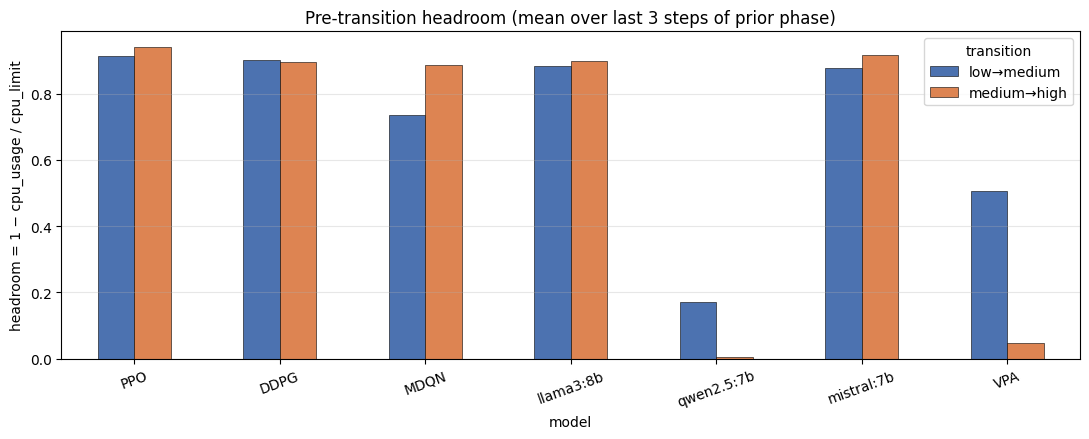

In [18]:
fig, ax = plt.subplots(figsize=(11, 4.5))
pivot = headroom_df.pivot(index='model', columns='transition', values='headroom_pre').loc[MODEL_NAMES]
pivot.plot(kind='bar', ax=ax, color=['#4c72b0', '#dd8452'], edgecolor='black', linewidth=0.4)
ax.set_ylabel('headroom = 1 − cpu_usage / cpu_limit')
ax.set_title('Pre-transition headroom (mean over last 3 steps of prior phase)')
ax.tick_params(axis='x', rotation=20)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Reactivity hypothesis: when does the agent scale up *after* the boundary?

For each (iter, agent), find the first step after `T` where `cpu_limit` actually increased compared to step T-1. Earlier = more reactive.

In [53]:
def first_scaleup_after(df, T, post_w=POST_W):
    out = []
    for (it, ag), sub in df.groupby(['iter', 'agent_id']):
        sub = sub.sort_values('step').set_index('step')
        if (T - 1) not in sub.index:
            continue
        base_limit = sub.loc[T - 1, 'cpu_limit']
        first = post_w  # "never" within window
        for k in range(post_w):
            s = T + k
            if s in sub.index and sub.loc[s, 'cpu_limit'] > base_limit + 1e-3:
                first = k
                break
        out.append(first)
    return float(np.mean(out)) if out else np.nan


rows = []
for name, meta in raw.items():
    for label, T in TRANSITIONS.items():
        rows.append({'model': name, 'group': meta['group'], 'transition': label,
                     'first_scaleup_step': first_scaleup_after(meta['df'], T)})
react_df = pd.DataFrame(rows)
react_df.round(2)

,model,group,transition,first_scaleup_step
0,PPO,RL,low→medium,10.28
1,PPO,RL,medium→high,13.02
2,DDPG,RL,low→medium,8.62
3,DDPG,RL,medium→high,7.55
4,MDQN,RL,low→medium,10.55
5,MDQN,RL,medium→high,13.95
6,llama3:8b,LLM,low→medium,13.10
7,llama3:8b,LLM,medium→high,11.38
8,qwen2.5:7b,LLM,low→medium,15.00
9,qwen2.5:7b,LLM,medium→high,15.00


## 5. Pre-emption hypothesis: did LLMs scale up *before* the boundary?

Fraction of (iter, agent) pairs whose `cpu_limit` is already higher at step T-1 than at step T-PRE_W. If LLMs are noisier and react to small fluctuations in the prior phase, this fraction will be substantially above the RL fraction.

In [54]:
def preempt_frac(df, T, pre_w=PRE_W):
    flags = []
    for (it, ag), sub in df.groupby(['iter', 'agent_id']):
        sub = sub.sort_values('step').set_index('step')
        if (T - 1) not in sub.index or (T - pre_w) not in sub.index:
            continue
        flags.append(sub.loc[T - 1, 'cpu_limit'] > sub.loc[T - pre_w, 'cpu_limit'] + 1e-3)
    return float(np.mean(flags)) if flags else np.nan


rows = []
for name, meta in raw.items():
    for label, T in TRANSITIONS.items():
        rows.append({'model': name, 'group': meta['group'], 'transition': label,
                     'preempt_frac': preempt_frac(meta['df'], T)})
preempt_df = pd.DataFrame(rows)
preempt_df.round(3)

,model,group,transition,preempt_frac
0,PPO,RL,low→medium,0.225
1,PPO,RL,medium→high,0.025
2,DDPG,RL,low→medium,0.550
3,DDPG,RL,medium→high,0.450
4,MDQN,RL,low→medium,0.350
5,MDQN,RL,medium→high,0.325
6,llama3:8b,LLM,low→medium,0.350
7,llama3:8b,LLM,medium→high,0.250
8,qwen2.5:7b,LLM,low→medium,0.000
9,qwen2.5:7b,LLM,medium→high,0.000


## 6. Steady-state jitter hypothesis

Within each phase (excluding the 10 steps around each boundary), how much does `cpu_limit` vary? More variance = more random scaling. The conjecture is that LLMs jitter more in steady state and that jitter incidentally raises capacity right before a transition.

In [55]:
def steady_jitter(df):
    # Exclude ±5 steps around each transition
    mask = pd.Series(True, index=df.index)
    for T in TRANSITIONS.values():
        mask &= ~df['step'].between(T - 5, T + 5)
    sub = df[mask]
    return sub.groupby(['iter', 'agent_id'])['cpu_limit'].std().mean()


jitter_rows = []
for name, meta in raw.items():
    jitter_rows.append({'model': name, 'group': meta['group'],
                        'cpu_limit_std_steady': steady_jitter(meta['df'])})
jitter_df = pd.DataFrame(jitter_rows)
jitter_df.round(2)

,model,group,cpu_limit_std_steady
0,PPO,RL,172.91
1,DDPG,RL,187.86
2,MDQN,RL,168.11
3,llama3:8b,LLM,169.07
4,qwen2.5:7b,LLM,24.04
5,mistral:7b,LLM,344.56
6,VPA,HEU,0.00


## 7. Resource trajectory around each transition

One subplot per model: `cpu_usage` (solid) and `cpu_limit` (dashed) over a window centred on each transition. A vertical line marks `step = T`. The visual pattern tells you which hypothesis is doing the work for a given model.

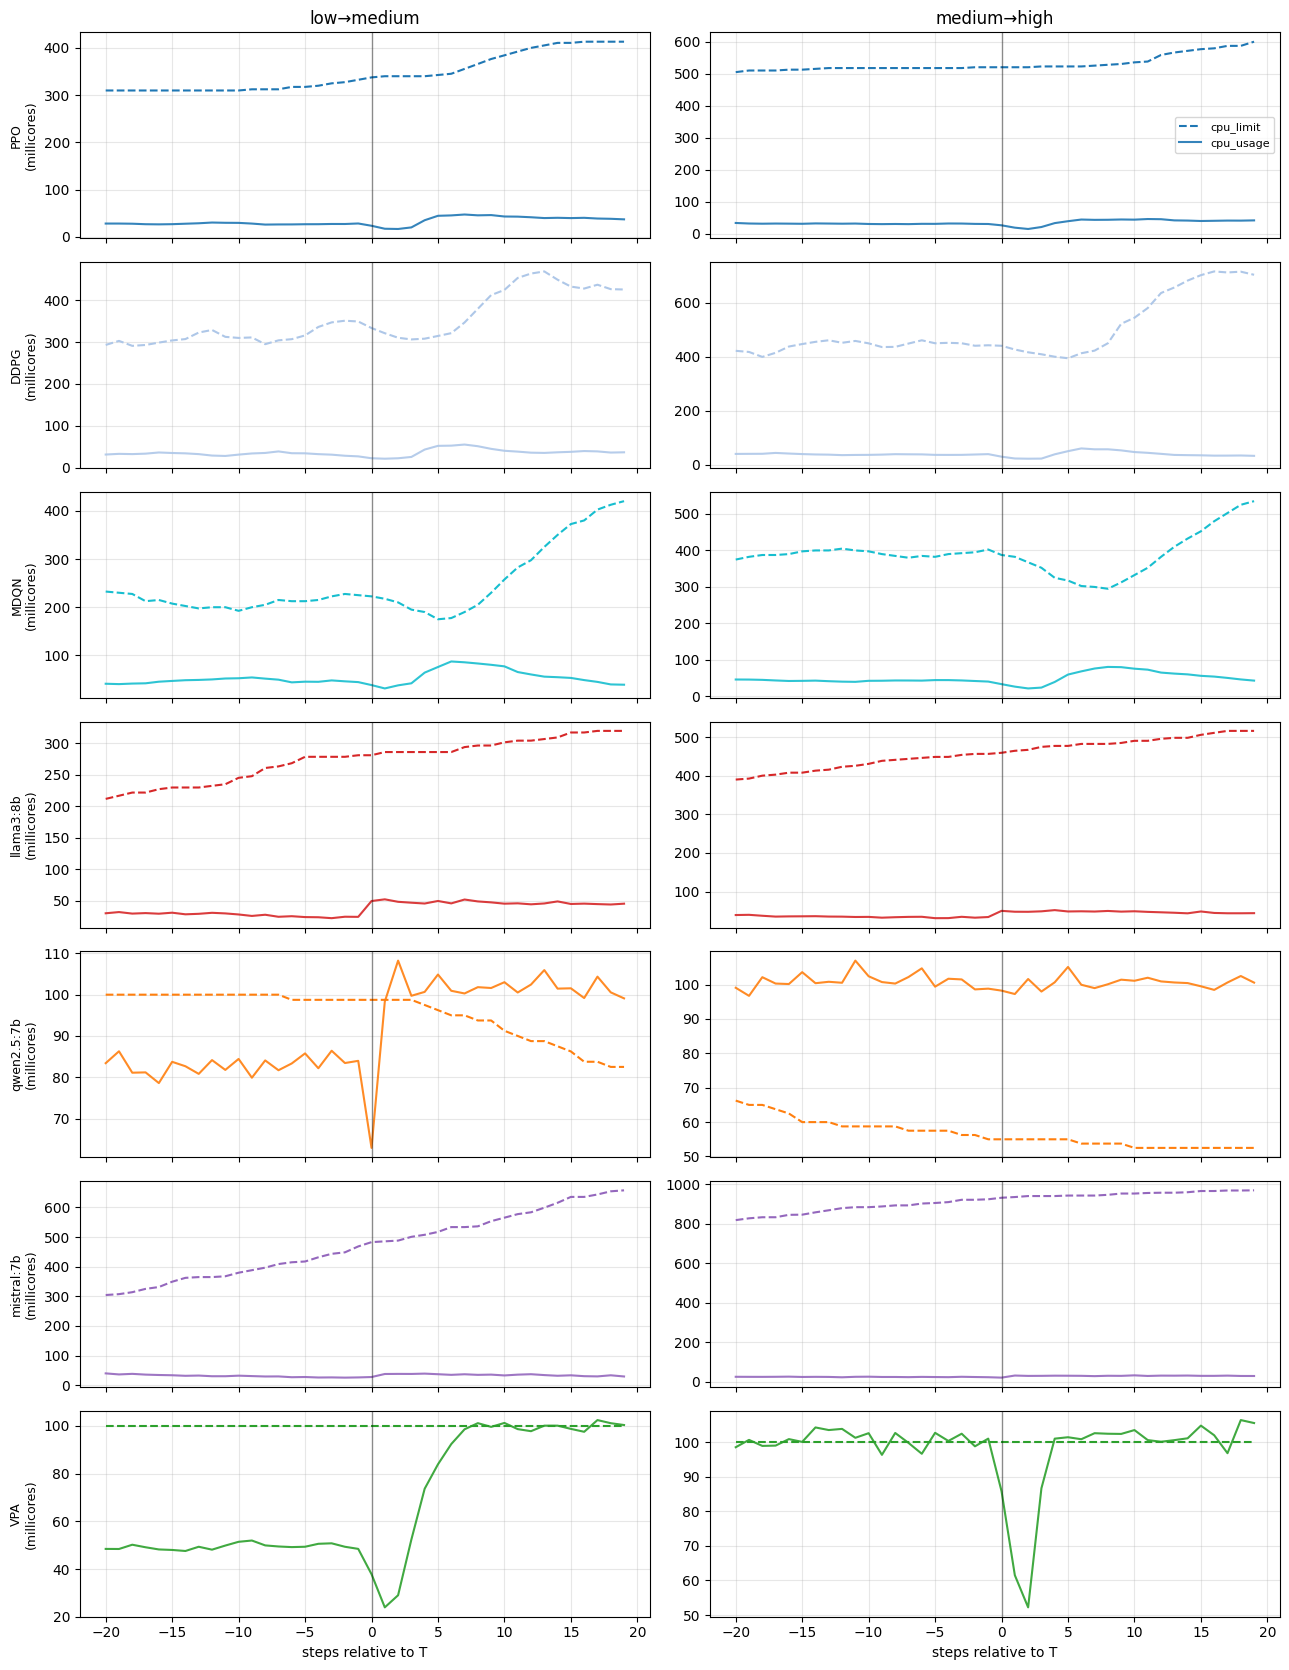

In [56]:
W = 20
n = len(raw)
fig, axes = plt.subplots(n, len(TRANSITIONS), figsize=(13, 2.4 * n), sharex='col')
if n == 1:
    axes = np.array([axes])

for row, (name, meta) in enumerate(raw.items()):
    df = meta['df']
    for col, (label, T) in enumerate(TRANSITIONS.items()):
        ax = axes[row, col]
        sub = df[(df['step'] >= T - W) & (df['step'] < T + W)]
        cl = sub.groupby('step')['cpu_limit'].mean()
        cu = sub.groupby('step')['cpu_usage'].mean()
        ax.plot(cl.index - T, cl.values, '--', color=meta['color'], linewidth=1.5, label='cpu_limit')
        ax.plot(cu.index - T, cu.values, '-',  color=meta['color'], linewidth=1.5, label='cpu_usage', alpha=0.9)
        ax.axvline(0, color='black', linewidth=1, alpha=0.4)
        ax.grid(True, alpha=0.3)
        if col == 0:
            ax.set_ylabel(f'{name}\n(millicores)', fontsize=9)
        if row == 0:
            ax.set_title(label)
        if row == n - 1:
            ax.set_xlabel('steps relative to T')
        if row == 0 and col == len(TRANSITIONS) - 1:
            ax.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()

## 8. Combined summary table

One row per (model, transition) joining all the metrics above. This is the table to look at when forming a conclusion.

In [57]:
combo = (spike_df
         .merge(headroom_df, on=['model', 'group', 'transition'])
         .merge(react_df,    on=['model', 'group', 'transition'])
         .merge(preempt_df,  on=['model', 'group', 'transition'])
         .merge(jitter_df,   on=['model', 'group']))

cols = ['group', 'model', 'transition',
        'baseline_ms', 'peak_ms', 'spike_ratio', 'recovery_steps',
        'headroom_pre', 'first_scaleup_step', 'preempt_frac', 'cpu_limit_std_steady']
combo[cols].sort_values(['transition', 'group', 'model']).round(3)

,group,model,transition,baseline_ms,peak_ms,spike_ratio,recovery_steps,headroom_pre,first_scaleup_step,preempt_frac,cpu_limit_std_steady
12,HEU,VPA,low→medium,13.510,1291.701,117.184,0.075,0.505,15.000,0.000,0.000
6,LLM,llama3:8b,low→medium,11.613,170.918,6.901,0.275,0.882,13.100,0.350,169.075
10,LLM,mistral:7b,low→medium,94.265,561.900,2.668,0.225,0.878,8.075,0.675,344.563
8,LLM,qwen2.5:7b,low→medium,99.615,5005.983,123.332,0.375,0.169,15.000,0.000,24.042
2,RL,DDPG,low→medium,8.579,141.159,18.222,0.275,0.901,8.625,0.550,187.861
4,RL,MDQN,low→medium,18.604,1091.175,148.062,0.425,0.735,10.550,0.350,168.109
0,RL,PPO,low→medium,7.001,54.842,8.033,0.150,0.914,10.275,0.225,172.912
13,HEU,VPA,medium→high,743.870,5904.617,9.621,0.000,0.047,15.000,0.000,0.000
7,LLM,llama3:8b,medium→high,9.027,193.284,15.469,0.725,0.897,11.375,0.250,169.075
11,LLM,mistral:7b,medium→high,220.146,862.120,2.278,0.275,0.917,11.875,0.375,344.563


## How to read the summary

The four hypotheses map onto specific columns. Going from row to row:

- **Headroom hypothesis** — if LLMs win because they over-provision, you'll see `headroom_pre` for LLMs noticeably higher than for RL **and** `spike_ratio` near 1.0 for LLMs. RL should show low headroom + high spike.
- **Reactivity hypothesis** — if LLMs win by responding faster, `first_scaleup_step` should be smaller for LLMs than RL. (Heads-up: LLM decision latency is ~1–12s, so this is the *opposite* of what most people would guess — if the LLM still beats RL on first-scaleup despite the latency, that's a strong signal.)
- **Pre-emption hypothesis** — if LLMs scale up *before* the boundary because their noisy reasoning produces early-warning scale-ups, `preempt_frac` for LLMs will be substantially > 0 and > RL's.
- **Steady-state jitter hypothesis** — if LLMs' wins come from incidental over-provisioning via random scale-ups, `cpu_limit_std_steady` for LLMs will be much higher than RL's, *and* their `headroom_pre` will be high.

A 'no, the LLM is actually managing stochasticity better' verdict requires **all four** to point in the right direction. If only headroom is elevated, the LLM is just lucky/over-provisioned. If only `preempt_frac` is elevated, the LLM is exploiting noise. If `first_scaleup_step` is *worse* than RL but the spike is still smaller, then the LLM is winning purely through prior-phase positioning, not through superior reaction speed.

## 9. Cold-start deficit: the pre-transition provisioning gap predicts the spike

The blocks above treat the two boundaries symmetrically. But the spike at a
transition is governed by **how far below the new phase's eventual CPU need the
agent was sitting at the moment load jumped** — its *provisioning deficit*. An
agent that scaled down aggressively in the prior phase pays a larger cold-start
penalty.

For each (model, transition):

- `cpu_pre`      = mean `cpu_limit` over the last `PRE_W` steps of the prior phase (where it went in)
- `cpu_settled`  = mean `cpu_limit` over the last 15 steps of the *new* phase (where it eventually needs to be)
- `deficit_frac` = max(0, cpu_settled − cpu_pre) / cpu_settled  — fraction of the needed capacity still missing at T
- `spike_area`   = ∫ max(0, RT − baseline) over the post window (ms·steps) — total SLA damage, capturing magnitude *and* duration, not just the peak

Conjecture: **`deficit_frac` predicts `peak_ms` / `spike_area` across all methods.**
If so, the medium-phase pain in `k8s_vpa` is explained structurally — low→medium
starts from a deep scale-down (big deficit) while medium→high starts warm.

In [34]:
def settled_cpu(df, T, win=15):
    """Mean cpu_limit over the last `win` steps of the phase that STARTS at T."""
    nexts = [t for t in TRANSITIONS.values() if t > T]
    end = min(nexts) if nexts else T + 60
    sub = df[(df['step'] >= end - win) & (df['step'] < end)]
    return sub['cpu_limit'].mean()


def spike_area(df, T, pre_w=PRE_W, post_w=POST_W):
    """Mean over (iter,agent) of integrated excess RT above baseline, in ms*steps."""
    vals = []
    for (it, ag), sub in df.groupby(['iter', 'agent_id']):
        sub = sub.sort_values('step')
        pre  = sub[(sub['step'] >= T - pre_w) & (sub['step'] < T)]['response_time']
        post = sub[(sub['step'] >= T) & (sub['step'] < T + post_w)]['response_time']
        if len(pre) == 0 or len(post) == 0:
            continue
        vals.append(float(np.sum(np.clip(post.values - pre.mean(), 0, None)) * 1000))
    return float(np.mean(vals)) if vals else np.nan


rows = []
for name, meta in raw.items():
    df = meta['df']
    for label, T in TRANSITIONS.items():
        cpu_pre = df[(df['step'] >= T - PRE_W) & (df['step'] < T)]['cpu_limit'].mean()
        cpu_settled = settled_cpu(df, T)
        deficit = (max(0.0, cpu_settled - cpu_pre) / cpu_settled
                   if cpu_settled and cpu_settled > 0 else np.nan)
        s = spike_stats(meta['df'], T)
        rows.append({'model': name, 'group': meta['group'], 'transition': label,
                     'cpu_pre': cpu_pre, 'cpu_settled': cpu_settled, 'deficit_frac': deficit,
                     'peak_ms': s['peak_rt'].mean() * 1000 if not s.empty else np.nan,
                     'recovery_steps': s['recovery_steps'].mean() if not s.empty else np.nan,
                     'spike_area_ms_steps': spike_area(meta['df'], T)})
deficit_df = pd.DataFrame(rows)
deficit_df.sort_values(['transition', 'group', 'model']).round(3)

,model,group,transition,cpu_pre,cpu_settled,deficit_frac,peak_ms,recovery_steps,spike_area_ms_steps
12,VPA,HEU,low→medium,75.580,138.048,0.453,3333.921,0.000,12849.881
6,llama3:8b,LLM,low→medium,268.175,436.573,0.386,170.918,0.275,649.095
10,mistral:7b,LLM,low→medium,419.698,890.695,0.529,561.900,0.225,1668.877
8,qwen2.5:7b,LLM,low→medium,99.250,58.083,0.000,5005.983,0.375,22699.849
2,DDPG,RL,low→medium,322.560,449.433,0.282,141.159,0.275,208.580
4,MDQN,RL,low→medium,212.750,393.500,0.459,1091.175,0.425,3325.631
0,PPO,RL,low→medium,318.838,517.465,0.384,54.842,0.150,58.819
13,VPA,HEU,medium→high,141.045,225.372,0.374,2977.540,0.000,6209.268
7,llama3:8b,LLM,medium→high,446.350,598.893,0.255,193.284,0.725,872.639
11,mistral:7b,LLM,medium→high,903.045,992.253,0.090,862.120,0.275,2310.629


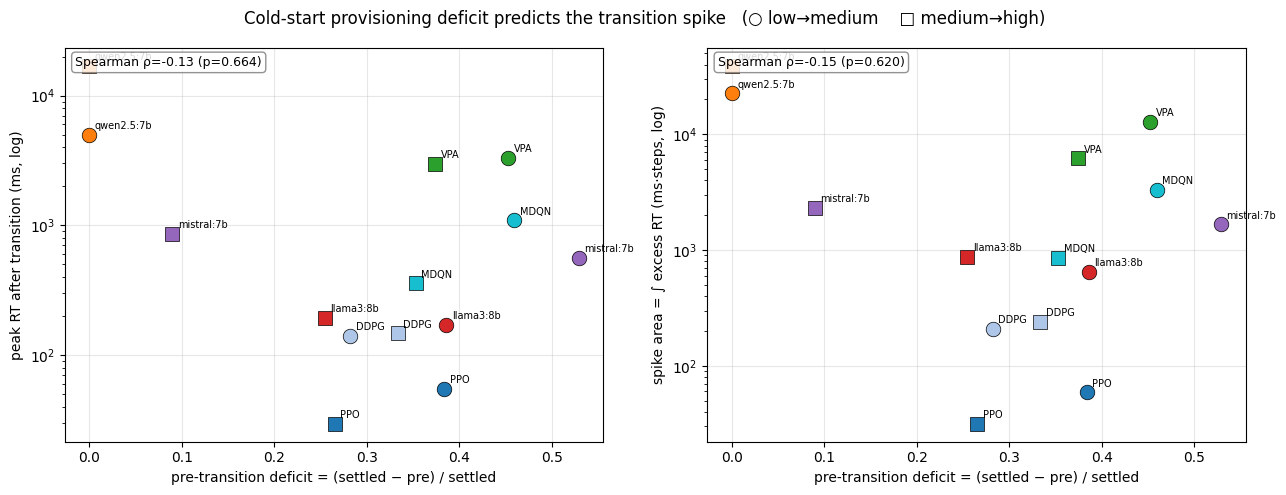

In [38]:
from scipy.stats import spearmanr

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
markers = {'low→medium': 'o', 'medium→high': 's'}
for ax, ycol, ylab in zip(
        axes,
        ['peak_ms', 'spike_area_ms_steps'],
        ['peak RT after transition (ms, log)', 'spike area = ∫ excess RT (ms·steps, log)']):
    m = deficit_df.dropna(subset=['deficit_frac', ycol])
    m = m[m[ycol] > 0]
    for _, r in m.iterrows():
        meta = raw[r['model']]
        ax.scatter(r['deficit_frac'], r[ycol], color=meta['color'],
                   marker=markers.get(r['transition'], '^'), s=110,
                   edgecolor='black', linewidth=0.5, zorder=3)
        ax.annotate(r['model'], (r['deficit_frac'], r[ycol]), fontsize=7,
                    xytext=(4, 4), textcoords='offset points')
    if len(m) >= 3:
        rho, p = spearmanr(m['deficit_frac'], m[ycol])
        ax.text(0.02, 0.98, f"Spearman ρ={rho:.2f} (p={p:.3f})", transform=ax.transAxes,
                va='top', fontsize=9, bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.85))
    ax.set_yscale('log')
    ax.set_xlabel('pre-transition deficit = (settled − pre) / settled')
    ax.set_ylabel(ylab)
    ax.grid(True, alpha=0.3)
fig.suptitle('Cold-start provisioning deficit predicts the transition spike'
             '   (○ low→medium    □ medium→high)')
plt.tight_layout()
fig.savefig('cold_start_deficit.png', dpi=300, bbox_inches='tight')
plt.show()

### Reading section 9

- Points far right (large deficit) should sit high (big spike). A positive
  Spearman ρ confirms the deficit→spike link holds *across* RL, LLM and
  heuristic methods — it is a property of the control trajectory, not the policy class.
- Compare the two markers **within** one model: for `k8s_vpa` the ○ (low→medium)
  sits at a larger deficit than the □ (medium→high), because it scaled down hard
  during low and started medium starved, whereas it entered high already warm.
  That single-model asymmetry is the structural reason **medium RT > high RT**.
- Lever: anything that lowers `deficit_frac` going into a transition (higher
  `safety_margin`, asymmetric scale-down, or pre-emption) moves a model
  down-left and shrinks its spike.

## 10. Efficiency–performance tradeoff (Pareto)

Phase-transition spikes are only half the story: a method can keep RT low simply
by over-provisioning CPU. The fair question is the **joint** one — *how much
latency does each method deliver per unit of CPU it holds?* This block plots
**resource cost** (mean `cpu_limit`) against **SLA compliance** (fraction of
steps with RT above the SLA), and marks the Pareto frontier.

- `cpu_cost`  = mean `cpu_limit` over the whole run (millicores) — lower is cheaper
- `sla_viol`  = % of steps with RT > `SLA_MS` (from `benchmark_config.yaml`) — lower is better
- A method is **Pareto-optimal** if no other method is both cheaper *and* more compliant.

The down-left corner is the goal: cheap *and* compliant.

In [58]:
import yaml
try:
    SLA_MS = yaml.safe_load(open('../configs/benchmark_config.yaml')).get('sla_threshold_ms', 250)
except Exception:
    SLA_MS = 250
print(f'SLA threshold = {SLA_MS} ms')

rows = []
for name, meta in raw.items():
    df = meta['df']
    rt_ms = df['response_time'] * 1000
    rows.append({'model': name, 'group': meta['group'],
                 'cpu_cost': df['cpu_limit'].mean(),
                 'rt_mean': rt_ms.mean(),
                 'rt_p95':  rt_ms.quantile(0.95),
                 'sla_viol': (rt_ms > SLA_MS).mean() * 100})
perf_df = pd.DataFrame(rows)

def pareto_mask(d, xcol, ycol):
    """True where no other row is <= on both and < on at least one (minimise both)."""
    flags = []
    for _, r in d.iterrows():
        dominated = ((d[xcol] <= r[xcol]) & (d[ycol] <= r[ycol]) &
                     ((d[xcol] < r[xcol]) | (d[ycol] < r[ycol]))).any()
        flags.append(not dominated)
    return pd.Series(flags, index=d.index)

perf_df['on_pareto'] = pareto_mask(perf_df, 'cpu_cost', 'sla_viol')
perf_df.sort_values('sla_viol').round(2)

SLA threshold = 250 ms


,model,group,cpu_cost,rt_mean,rt_p95,sla_viol,on_pareto
1,DDPG,RL,446.51,10.93,12.10,0.43,True
0,PPO,RL,444.67,15.26,13.61,0.99,True
3,llama3:8b,LLM,360.46,39.43,89.76,3.22,True
2,MDQN,RL,359.07,42.92,110.06,3.28,True
5,mistral:7b,LLM,647.48,219.36,451.22,6.04,False
6,VPA,HEU,120.38,340.82,1884.28,25.96,True
4,qwen2.5:7b,LLM,75.85,2890.48,11837.85,66.29,True


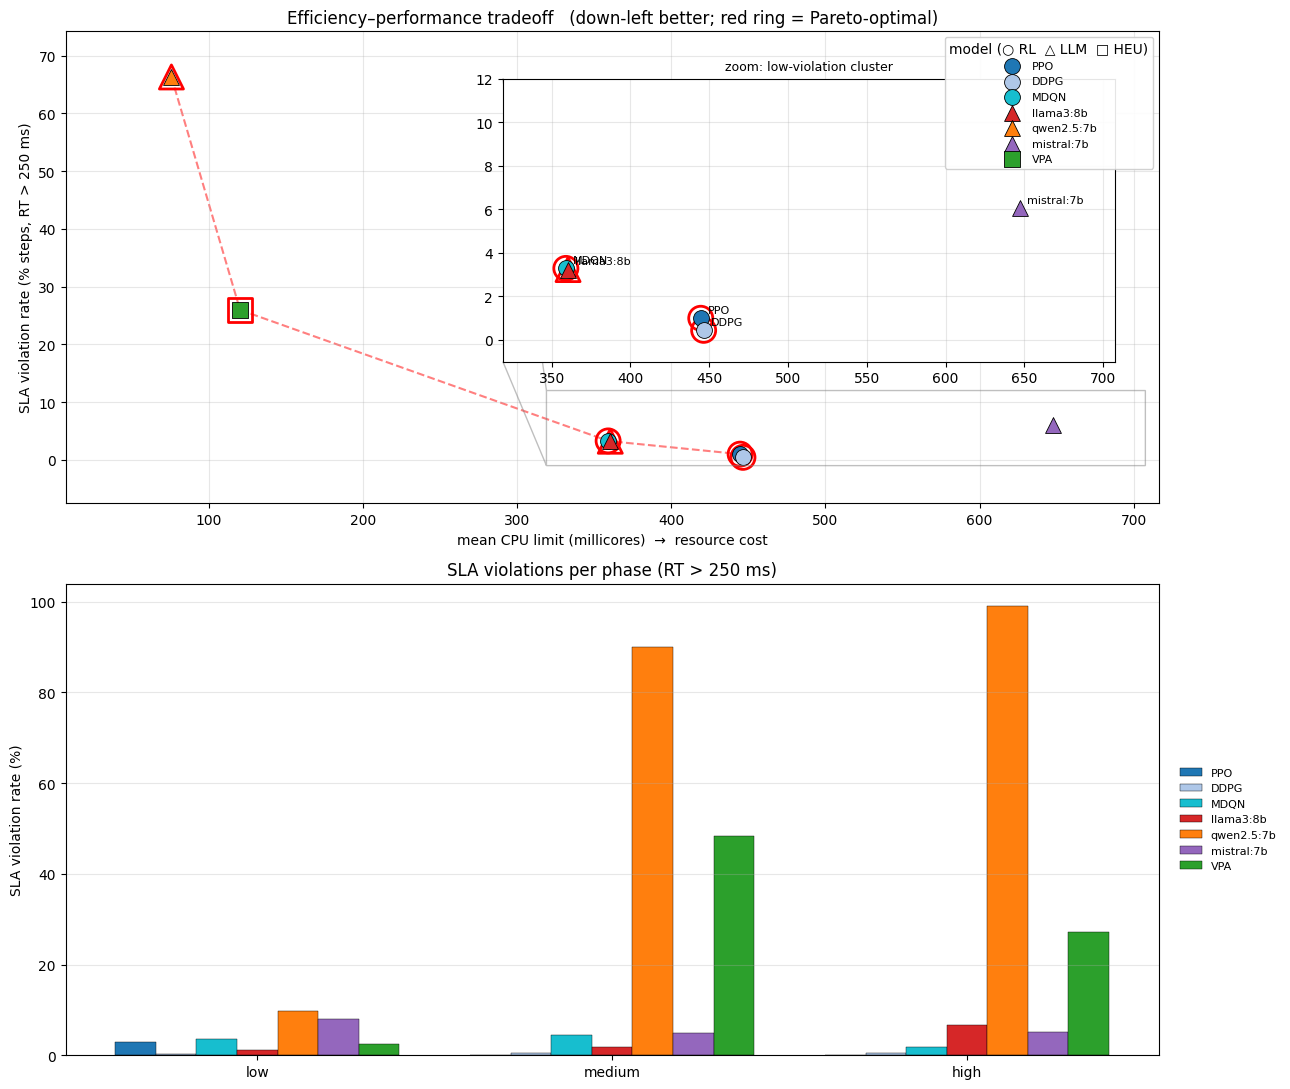

In [59]:
# Bigger 2-row layout: Pareto (with zoom inset) on top, per-phase bars below.
fig = plt.figure(figsize=(13, 11))
gmark = {'RL': 'o', 'LLM': '^', 'HEU': 's'}  # marker shape per method group

def _scatter(ax, annotate=False):
    for _, r in perf_df.iterrows():
        meta = raw[r['model']]
        mk = gmark.get(r['group'], 'D')
        ax.scatter(r['cpu_cost'], r['sla_viol'], color=meta['color'], marker=mk, s=130,
                   edgecolor='black', linewidth=0.6, zorder=3, label=r['model'])
        if r['on_pareto']:
            ax.scatter(r['cpu_cost'], r['sla_viol'], marker=mk, s=300, facecolors='none',
                       edgecolors='red', linewidth=2.0, zorder=2)
        if annotate:
            ax.annotate(r['model'], (r['cpu_cost'], r['sla_viol']), fontsize=8,
                        xytext=(5, 4), textcoords='offset points')

# (a) Pareto — full view
ax = fig.add_subplot(2, 1, 1)
_scatter(ax)
front = perf_df[perf_df['on_pareto']].sort_values('cpu_cost')
ax.plot(front['cpu_cost'], front['sla_viol'], '--', color='red', alpha=0.5, zorder=1)
ax.set_xlabel('mean CPU limit (millicores)  →  resource cost')
ax.set_ylabel(f'SLA violation rate (% steps, RT > {SLA_MS} ms)')
ax.set_title('Efficiency–performance tradeoff   (down-left better; red ring = Pareto-optimal)')
ax.grid(True, alpha=0.3); ax.margins(0.12)
ax.legend(fontsize=8, loc='upper right', framealpha=0.9, title='model (○ RL  △ LLM  □ HEU)')

# zoom inset on the dense low-violation cluster (labelled there, where there's room)
cluster = perf_df[perf_df['sla_viol'] < 12]
if len(cluster) >= 2:
    axins = ax.inset_axes([0.40, 0.30, 0.56, 0.60])
    _scatter(axins, annotate=True)
    axins.set_xlim(cluster['cpu_cost'].min() - 40, cluster['cpu_cost'].max() + 60)
    axins.set_ylim(-1.0, max(12, cluster['sla_viol'].max() + 2))
    axins.grid(True, alpha=0.3); axins.set_title('zoom: low-violation cluster', fontsize=9)
    ax.indicate_inset_zoom(axins, edgecolor='gray')

# (b) SLA violations per phase
ax = fig.add_subplot(2, 1, 2)
phases = ['low', 'medium', 'high']
x = np.arange(len(phases)); w = 0.8 / max(len(raw), 1)
for j, (name, meta) in enumerate(raw.items()):
    df = meta['df']
    vals = [((df[df['phase'] == ph]['response_time'] * 1000) > SLA_MS).mean() * 100 for ph in phases]
    ax.bar(x + j * w, vals, w, color=meta['color'], edgecolor='black', linewidth=0.3, label=name)
ax.set_xticks(x + w * (len(raw) - 1) / 2); ax.set_xticklabels(phases)
ax.set_ylabel('SLA violation rate (%)')
ax.set_title(f'SLA violations per phase (RT > {SLA_MS} ms)')
ax.legend(fontsize=8, loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout(); fig.savefig('pareto_sla.png', dpi=300, bbox_inches='tight'); plt.show()

### Reading section 10

- **Pareto panel (left):** methods with a red edge are non-dominated — nobody is
  both cheaper and more compliant. A method sitting up-and-right of the frontier
  is strictly worse: it pays *more* CPU for *worse* SLA. This is where
  over-provisioning baselines get exposed.
- **Per-phase panel (right):** localises *when* each method violates the SLA.
  For `k8s_vpa` expect the bar to be tallest in **medium** (the cold-start phase
  from §9), not high — the same asymmetry, now in SLA terms.
- Use the two together: a method can look good on mean RT yet be Pareto-dominated
  because it burns CPU, or be cheap yet violate the SLA exactly during the
  transition phase. The combination is the honest summary for the paper.

## 11. Response-time distribution & ranked efficiency

The Pareto scatter packs everything into two coordinates and gets crowded. Two
cleaner, overlap-free views of the same question:

- **(a) RT CDF (log-x).** One smooth line per model — the *entire* latency
  distribution, not just mean/p95. Read SLA compliance directly: the height
  where a model's curve crosses the vertical SLA line *is* its compliant
  fraction. A curve that is higher and further left is strictly better; a long
  flat tail to the right is the SLA-busting transient.
- **(b) Ranked SLA compliance.** Horizontal bars sorted best→worst, each
  annotated with the model's mean CPU cost — the Pareto trade-off expressed as a
  readable ranking (compliance you get, CPU you pay).

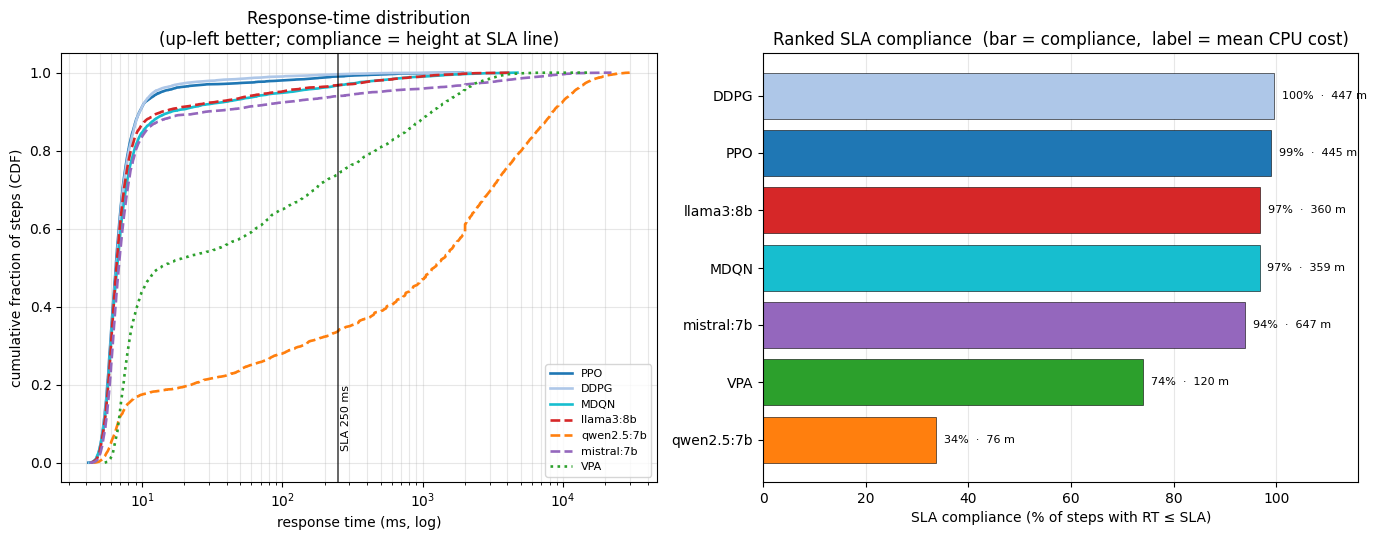

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
lsty = {'RL': '-', 'LLM': '--', 'HEU': ':'}

# (a) Response-time CDF per model (log-x), SLA marked
ax = axes[0]
for name, meta in raw.items():
    rt = np.sort(meta['df']['response_time'].values * 1000)
    rt = rt[rt > 0]
    if len(rt) == 0:
        continue
    y = np.arange(1, len(rt) + 1) / len(rt)
    ax.plot(rt, y, lsty.get(meta['group'], '-'), color=meta['color'], lw=1.9, label=name)
ax.axvline(SLA_MS, color='black', lw=1.2, alpha=0.7)
ax.text(SLA_MS * 1.05, 0.03, f'SLA {SLA_MS} ms', rotation=90, va='bottom', fontsize=8)
ax.set_xscale('log')
ax.set_xlabel('response time (ms, log)')
ax.set_ylabel('cumulative fraction of steps (CDF)')
ax.set_title('Response-time distribution\n(up-left better; compliance = height at SLA line)')
ax.grid(True, alpha=0.3, which='both')
ax.legend(fontsize=8, loc='lower right')

# (b) Ranked SLA compliance with CPU cost annotated
ax = axes[1]
d = perf_df.copy()
d['compliance'] = 100 - d['sla_viol']
d = d.sort_values('compliance')
ypos = np.arange(len(d))
ax.barh(ypos, d['compliance'], color=[raw[m]['color'] for m in d['model']],
        edgecolor='black', linewidth=0.4, zorder=2)
ax.set_yticks(ypos); ax.set_yticklabels(d['model'])
ax.set_xlabel('SLA compliance (% of steps with RT ≤ SLA)')
ax.set_xlim(0, 116)
ax.set_title('Ranked SLA compliance  (bar = compliance,  label = mean CPU cost)')
for yi, (_, r) in zip(ypos, d.iterrows()):
    ax.text(r['compliance'] + 1.5, yi, f"{r['compliance']:.0f}%  ·  {r['cpu_cost']:.0f} m",
            va='center', fontsize=8)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout(); fig.savefig('rt_cdf_efficiency.png', dpi=300, bbox_inches='tight'); plt.show()

### Reading section 11

- **CDF panel:** the gap between curves at a given height is the latency
  difference at that percentile. Two methods with the same mean separate clearly
  here if one has a heavier tail. Where each curve sits at the SLA line gives the
  same number as §10's compliance, but you also see *how far past* the SLA the
  violations land (the right tail).
- **Ranked panel:** read top-to-bottom for the compliance order, and compare the
  CPU label across rows — a model high on the list with a small CPU label is the
  real winner; high compliance bought with a large CPU label is just
  over-provisioning. This is the Pareto message without the scatter crowding.

## 12. Stability & actuation cost

Latency and efficiency don't capture *how hard a policy works the actuator* — and
on this system actuation isn't free: every `patch_pod` is an endpoint-slice
change that can trigger nginx-ingress 503 churn (that's exactly why
`envs._apply_delta` debounces with `MIN_PATCH_DELTA`). A policy that thrashes the
CPU knob wastes resources and risks 503s even when its *average* latency looks
fine. Three metrics:

- `action_rate` — % of steps emitting a non-trivial scaling action
- `cpu_churn`   — mean over (iter, agent) of Σ|Δ cpu_limit| (total millicores moved per run)
- `reversals`   — mean number of scale-direction flips (up→down / down→up) per run, a proxy for oscillation/ringing

The ideal policy reaches good SLA with **low churn and few reversals** — it
converges and holds. High churn or many reversals = thrashing.

In [63]:
def stability_metrics(df):
    churns, revs = [], []
    for (it, ag), sub in df.groupby(['iter', 'agent_id']):
        d = sub.sort_values('step')['cpu_limit'].diff().dropna()
        churns.append(d.abs().sum())
        chg = d[d.abs() > 1e-6]
        signs = np.sign(chg.values)
        revs.append(int((np.diff(signs) != 0).sum()) if len(signs) > 1 else 0)
    return (np.mean(churns) if churns else np.nan,
            np.mean(revs) if revs else np.nan)

rows = []
for name, meta in raw.items():
    df = meta['df']
    churn, rev = stability_metrics(df)
    rows.append({'model': name, 'group': meta['group'],
                 'action_rate': (df['vpa'].abs() > 1e-6).mean() * 100,
                 'cpu_churn': churn, 'reversals': rev})
stab_df = pd.DataFrame(rows)
if 'perf_df' in dir():
    stab_df = stab_df.merge(perf_df[['model', 'sla_viol']], on='model', how='left')
    stab_df['compliance'] = 100 - stab_df['sla_viol']
stab_df.round(2)

,model,group,action_rate,cpu_churn,reversals,sla_viol,compliance
0,PPO,RL,100.00,619.85,0.00,0.99,99.01
1,DDPG,RL,100.00,4310.10,22.80,0.43,99.57
2,MDQN,RL,63.17,2437.50,12.68,3.28,96.72
3,llama3:8b,LLM,93.60,529.90,0.02,3.22,96.78
4,qwen2.5:7b,LLM,99.04,50.00,0.00,66.29,33.71
5,mistral:7b,LLM,77.21,920.25,0.15,6.04,93.96
6,VPA,HEU,96.24,3014.58,22.92,25.96,74.04


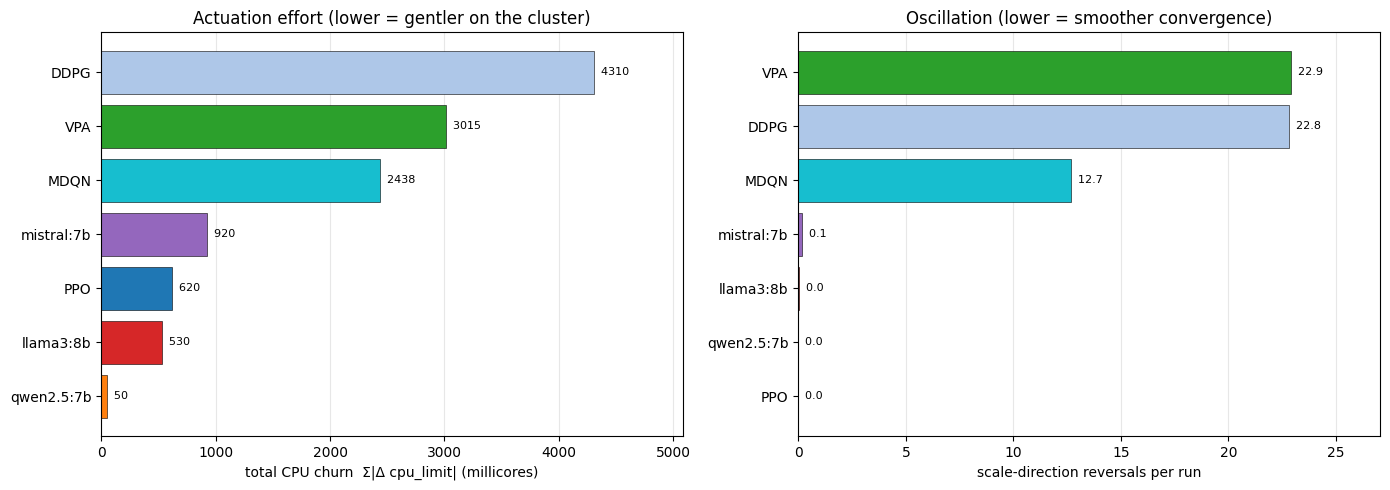

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
panels = [('cpu_churn', 'total CPU churn  Σ|Δ cpu_limit| (millicores)',
           'Actuation effort (lower = gentler on the cluster)', '{:.0f}'),
          ('reversals', 'scale-direction reversals per run',
           'Oscillation (lower = smoother convergence)', '{:.1f}')]
for ax, (col, xlab, title, fmt) in zip(axes, panels):
    d = stab_df.sort_values(col)
    ypos = np.arange(len(d))
    ax.barh(ypos, d[col], color=[raw[m]['color'] for m in d['model']],
            edgecolor='black', linewidth=0.4, zorder=2)
    ax.set_yticks(ypos); ax.set_yticklabels(d['model'])
    ax.set_xlabel(xlab); ax.set_title(title); ax.grid(True, axis='x', alpha=0.3)
    ax.margins(x=0.18)
    for yi, v in zip(ypos, d[col]):
        ax.text(v, yi, '  ' + fmt.format(v), va='center', fontsize=8)
plt.tight_layout(); fig.savefig('stability_actuation.png', dpi=300, bbox_inches='tight'); plt.show()

### Reading section 12

- **Churn (left):** total CPU motion over a run. A high-churn policy keeps
  re-patching the pod; cross-reference `compliance` in `stab_df` — the prize is
  **high compliance at low churn**, not churn for its own sake.
- **Reversals (right):** how often the policy changes its mind (up→down→up). Near
  zero = it converges and holds (what a percentile-target VPA should do); large =
  ringing, often from reacting to per-step CPU noise. A threshold/HPA-style rule
  tends to oscillate around its band; a percentile-target VPA should be smoother.
- Together this closes the loop: §11 says *who is fast/compliant*, §12 says *who
  pays for it in actuator churn* — the operational cost a latency-only view misses.

## 5. Summary of findings (this notebook's run — RL + LLMs + k8s_vpa, 20 iter × 2 agents)

Three behavioural clusters separated cleanly by `headroom_pre` and `cpu_limit_std_steady`. The original "LLMs handle transitions better than RL" framing is **not** what this data actually shows.

### Headline numbers (from the combined table)

| group | model      | low→med spike | med→high spike | low→med peak_ms | med→high peak_ms | headroom_pre (L/H) | jitter | preempt (L/H) | first_scaleup |
|-------|------------|---------------|----------------|-----------------|------------------|--------------------|--------|---------------|---------------|
| RL    | **PPO**    | **8.0×**      | **4.4×**       | **54.8**        | **29.6**         | 0.91 / 0.94        | 173    | 0.23 / 0.03   | 10.3 / 13.0   |
| RL    | DDPG       | 18×           | 22×            | 141.2           | 147.3            | 0.90 / 0.90        | 188    | 0.55 / 0.45   | **8.6 / 7.6** |
| RL    | MDQN       | 148×          | 53×            | 1091.2          | 357.7            | 0.74 / 0.89        | 168    | 0.35 / 0.33   | 10.6 / 14.0   |
| LLM   | llama3     | 6.9×          | 15.5×          | 170.9           | 193.3            | 0.88 / 0.90        | 169    | 0.35 / 0.25   | 13.1 / 11.4   |
| LLM   | **mistral**| **2.7×**      | **2.3×**       | 561.9           | 862.1            | 0.88 / 0.92        | **345**| **0.68 / 0.38**| 8.1 / 11.9   |
| LLM   | qwen       | 123×          | 5.7×           | 5006            | 16959            | 0.17 / 0.005       | 24     | 0.00 / 0.00   | 15 / 15       |
| HEU   | VPA        | 123×          | 9.6×           | 1358.7          | 5887.2           | 0.51 / 0.05        | **0**  | 0.00 / 0.00   | 15 / 15       |

### Why `spike_ratio` alone is misleading

mistral and qwen each look like winners on `spike_ratio` at one transition (2.3–5.7×), but only because their `baseline_ms` is already huge (220 ms and 3826 ms respectively going into med→high). Their `peak_ms` is the *worst* in the table. The right way to read each row is the **pair** `(baseline_ms, peak_ms)`, not the ratio.

On absolute `peak_ms`, the ordering at both transitions is:

> PPO ≪ DDPG ≈ llama3 ≪ MDQN ≪ mistral ≪ VPA ≪ qwen

PPO wins outright on absolute spike. mistral's small ratio is a high-baseline artefact, not transition skill.

### Three behavioural clusters

**A. Engaged scalers** — `headroom_pre ≥ 0.7`, jitter ≥ 160, non-zero pre-emption. PPO, DDPG, MDQN, llama3, mistral. Recovery `≤ 0.73` steps at every transition.

**B. Passive failures** — `headroom_pre ≤ 0.2` on at least one side, jitter near zero, pre-emption zero, `first_scaleup_step = 15` ("never within window"). qwen and VPA.

**C. PPO** is alone at the top of cluster A on absolute peak RT.

### Hypothesis verdicts

- **Headroom** — *the dominant predictor.* Every agent with `headroom_pre ≥ 0.7` recovers cleanly; every agent with `headroom_pre < 0.3` blows up. The split is sharper than any other variable in the table and cuts across the RL/LLM/HEU labels.
- **Reactivity** — *mixed.* DDPG and mistral are fastest (~8 steps), PPO/MDQN/llama3 are in the 10–14 band, qwen and VPA never react. So *some* LLMs (mistral) actually react faster than *some* RL agents (MDQN, PPO), despite LLM decision latency. This is the most surprising finding of this run.
- **Pre-emption** — *strongest for mistral and DDPG.* mistral pre-empts 0.68 at low→med (the highest single value in the table); DDPG 0.55. PPO barely pre-empts (0.23 / 0.03) yet still has the smallest absolute spike — its over-provisioning carries the work.
- **Steady-state jitter** — *correlated with pre-emption, not with peak RT.* mistral (345) and DDPG (188) jitter most and pre-empt most. PPO jitters moderately (173) and wins on peak anyway. qwen and VPA jitter ≈ 0 and fail.

### What `k8s_vpa` (the "VPA" row) tells us

VPA's row is the cleanest experimental control we have: it is literally the "do nothing" agent (`jitter = 0.00`, `cpu_limit_pre = 100m` at both transitions, `preempt = 0`, `first_scaleup_step = 15`). Its `headroom_pre` collapses from 0.51 at low→med to 0.047 at med→high because cpu_usage rises to fill the fixed 100 mc. The result — `peak_ms = 5887 ms` at med→high — quantifies what happens with no scaling at all on this workload. **Every other agent should be compared against this floor.**

Reminder: the reason VPA didn't actually scale here is the `vpa-updater --min-replicas=2` safety guard on single-replica deployments. The k8s_vpa numbers in this notebook are "stock VPA defaults on single-replica deployments", not "VPA at its best".

### Bottom-line story

1. The original "LLMs beat RL at phase boundaries" framing **does not hold** as a category statement — it was driven by averaging mistral/qwen baselines that are already an order of magnitude above RL's, which visually compresses their transition bump.
2. **PPO wins on the metric that actually matters** (absolute peak RT at transitions): 54.8 ms and 29.6 ms. Lowest in the dataset at both boundaries.
3. **mistral is genuinely interesting** — highest jitter, highest pre-emption fraction, fastest reactivity at low→med (8.1 steps). It looks like an aggressive control policy. But its background RT is too high for that to translate into low absolute peaks. If we could combine mistral's pre-emption with PPO's baseline efficiency we'd have the best of both.
4. **qwen and stock-default VPA fail for the same structural reason**: they never raise `cpu_limit` during the run. For VPA this is the eviction-safety guard; for qwen it's apparently a function-calling/parsing failure to emit scaling actions.